# Objectives

- Handle missing values
- Removing features with no useful information
- Cleaning categorical and numerical variables
- Looking for outliers
- Checking for duplicates

# Imports

In [1]:
import pandas as pd
import math
import random
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import sklearn
from sklearn.metrics import classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix, accuracy_score,
                             mean_absolute_error, mean_squared_error, r2_score)
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import LabelEncoder
import time
import plotly.express as px
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.neighbors import NearestNeighbors
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12
plt.rcParams['legend.fontsize'] = 10
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap.umap_ as umap

# Helper Functions

In [2]:
def find_and_display_duplicates(df_data):
    duplicated_rows = df_data[df_data.duplicated(keep=False)]

    if not duplicated_rows.empty:
        print(f"Se encontraron {len(duplicated_rows)}")
    else:
        print("No se encontraron filas duplicadas.")
    return duplicated_rows

In [3]:
def plot_outliers_boxplot(df_data):

    num_plots = len(numerical_features)

    if num_plots == 0:
        print("No numerical features found")
        return

    if num_plots == 1:
        nrows, ncols = 1, 1
    elif num_plots == 2:
        nrows, ncols = 1, 2
    elif num_plots <= 4:
        nrows, ncols = 2, 2
    else:
        nrows = (num_plots + 1) // 3 
        ncols = 3

    fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 5 * nrows))
    fig.suptitle('Outliers visualization/ Boxplot', fontsize=16)

    if num_plots == 1:
        axes_flat = [axes]
    else:
        axes_flat = axes.flatten()

    for i, col in enumerate(numerical_features):
        if i < len(axes_flat):
            sns.boxplot(y=df_data[col], ax=axes_flat[i], color='lightsteelblue')
            axes_flat[i].set_title(f'{col} boxplot')
            axes_flat[i].set_ylabel(col)

    for j in range(num_plots, len(axes_flat)):
        fig.delaxes(axes_flat[j])

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

# Load Dataset

In [4]:
df = pd.read_csv(r'C:\Users\Usuario\Proyectos\Trabajos\Diabetes readmission prediction\data\Raw/diabetic_data.csv')
print(df.shape)
df.head()

(101766, 50)


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


# Remove unnecesary features

- Based on EDA, *weight* presented 95% missing values, so it´ll be removed.
- Based on EDA, *patient_nbr* represents an ID, and repeated values can be evaluated with other features in this dataset. This feature will be removed due to lack of useful practical information for this project.
- EDA found *payer_code* had ~40% missingness, after weighting its interpretability and null entries with its value as predictive information, I´ve decided to remove this feature. 

In [5]:
df.drop(columns=["weight", "patient_nbr", "payer_code"], inplace=True)

# Handling missing values

## A1Cresult and max_glu_serum

For both test related to diabetes, there was a trend during EDA showing patients with a recorded test had a slightly higher readmission rate.

max_glu_serum also showed progressively higher readmission for higher glucose values. 

===============================================================================================

All unknown values are transformed to "Not measured". 

- Given the high missing information, it´d be a huge loss of information to delete every NaN.
- "Not measured" gives information of a deliberate decission to not take the test to the patient
- "Not measured" also works as a baseline for a common patient with no background related to diabetes, and therefore no tests taken
- Information for the tests performed is still kept and will be useful predictive information.


In [6]:
df["max_glu_serum"] = df["max_glu_serum"].fillna("Not measured")
df["A1Cresult"] = df["A1Cresult"].fillna("Not measured")

## race

This feature presents ~2% missing values. There´s no reason to drop the feature, and in order to keep all entries in the dataset, all null values will be transformed to "unknown"

In [7]:
df["race"] = df["race"].replace("?", "Unknown")

## medical_speciality

About half the values are missing in this feature. 

The information provided can be useful, so this variable will be kept.

With so many unrecorded entries, imputing to mode or median would leave very unreliable data.

All missing values will be transformed to "unknown".

In [8]:
df["medical_specialty"] = df["medical_specialty"].replace("?", "Unknown")

# Cleaning

## Mapping identifier columns

Columns admission_type_id, discharge_disposition_id and admission_source_id contain ID numbers. Using the IDS_mapping excel sheet from the source material, these features will be translated to their descriptions.

Note: I made the dictionaries manually because of how IDS_mapping is ordered. 

### admission_type

In [9]:
admission_type_dict = {
    1: "Emergency",
    2: "Urgent",
    3: "Elective",
    4: "Newborn",
    5: "Not Available",
    6: "NULL",
    7: "Trauma Center",
    8: "Not Mapped"
}

In [10]:
df["admission_type"] = df["admission_type_id"].map(admission_type_dict)

In [11]:
df['admission_type'].value_counts()

admission_type
Emergency        53990
Elective         18869
Urgent           18480
NULL              5291
Not Available     4785
Not Mapped         320
Trauma Center       21
Newborn             10
Name: count, dtype: int64

In [12]:
df.drop(columns="admission_type_id", inplace=True)

### discharge_disposition

In [13]:
discharge_disposition_dict = {
    1: "Discharged to home",
    2: "Discharged/transferred to another short term hospital",
    3: "Discharged/transferred to SNF",
    4: "Discharged/transferred to ICF",
    5: "Discharged/transferred to another type of inpatient care institution",
    6: "Discharged/transferred to home with home health service",
    7: "Left AMA",
    8: "Discharged/transferred to home under care of Home IV provider",
    9: "Admitted as an inpatient to this hospital",
    10: "Neonate discharged to another hospital for neonatal aftercare",
    11: "Expired",
    12: "Still patient or expected to return for outpatient services",
    13: "Hospice / home",
    14: "Hospice / medical facility",
    15: "Discharged/transferred within this institution to Medicare approved swing bed",
    16: "Discharged/transferred/referred another institution for outpatient services",
    17: "Discharged/transferred/referred to this institution for outpatient services",
    18: "NULL",
    19: "Expired at home. Medicaid only, hospice.",
    20: "Expired in a medical facility. Medicaid only, hospice.",
    21: "Expired, place unknown. Medicaid only, hospice.",
    22: "Discharged/transferred to another rehab fac including rehab units of a hospital .",
    23: "Discharged/transferred to a long term care hospital.",
    24: "Discharged/transferred to a nursing facility certified under Medicaid but not certified under Medicare.",
    25: "Not Mapped",
    26: "Unknown/Invalid",
    27: "Discharged/transferred to a federal health care facility.",
    28: "Discharged/transferred/referred to a psychiatric hospital of psychiatric distinct part unit of a hospital",
    29: "Discharged/transferred to a Critical Access Hospital (CAH).",
    30: "Discharged/transferred to another Type of Health Care Institution not Defined Elsewhere"
}

In [14]:
df["discharge_disposition"] = df["discharge_disposition_id"].map(discharge_disposition_dict)

In [15]:
df['discharge_disposition'].value_counts()

discharge_disposition
Discharged to home                                                                                           60234
Discharged/transferred to SNF                                                                                13954
Discharged/transferred to home with home health service                                                      12902
NULL                                                                                                          3691
Discharged/transferred to another short term hospital                                                         2128
Discharged/transferred to another rehab fac including rehab units of a hospital .                             1993
Expired                                                                                                       1642
Discharged/transferred to another type of inpatient care institution                                          1184
Not Mapped                                                

In [16]:
df.drop(columns= "discharge_disposition_id", inplace=True)

### admission_source

In [17]:
admission_source_dict = {
    1: "Physician Referral",
    2: "Clinic Referral",
    3: "HMO Referral",
    4: "Transfer from a hospital",
    5: "Transfer from a Skilled Nursing Facility (SNF)",
    6: "Transfer from another health care facility",
    7: "Emergency Room",
    8: "Court/Law Enforcement",
    9: "Not Available",
    10: "Transfer from critial access hospital",
    11: "Normal Delivery",
    12: "Premature Delivery",
    13: "Sick Baby",
    14: "Extramural Birth",
    15: "Not Available",
    17: "NULL",
    18: "Transfer From Another Home Health Agency",
    19: "Readmission to Same Home Health Agency",
    20: "Not Mapped",
    21: "Unknown/Invalid",
    22: "Transfer from hospital inpt/same fac reslt in a sep claim",
    23: "Born inside this hospital",
    24: "Born outside this hospital",
    25: "Transfer from Ambulatory Surgery Center",
    26: "Transfer from Hospice"
}

In [18]:
df['admission_source'] = df['admission_source_id'].map(admission_source_dict)

In [19]:
df['admission_source'].value_counts(dropna=False)

admission_source
Emergency Room                                               57494
Physician Referral                                           29565
NULL                                                          6781
Transfer from a hospital                                      3187
Transfer from another health care facility                    2264
Clinic Referral                                               1104
Transfer from a Skilled Nursing Facility (SNF)                 855
HMO Referral                                                   187
Not Mapped                                                     161
Not Available                                                  125
Court/Law Enforcement                                           16
Transfer from hospital inpt/same fac reslt in a sep claim       12
Transfer from critial access hospital                            8
Extramural Birth                                                 2
Normal Delivery                              

In [20]:
df.drop(columns = "admission_source_id", inplace = True)

## Feature classification

In [21]:
numerical_features = [
    "time_in_hospital",
    "num_procedures",
    "num_lab_procedures",
    "num_medications",
    "number_outpatient",
    "number_emergency",
    "number_inpatient",
    "number_diagnoses"
]

In [22]:
categorical_features = [
    col for col in df.columns
    if col not in numerical_features
]

## Categorical variables

In [23]:
for feature in categorical_features:
    print(f"\n{feature}")
    display(df[feature].value_counts(dropna=False))


encounter_id


encounter_id
2278392      1
149190       1
64410        1
500364       1
16680        1
            ..
443847548    1
443847782    1
443854148    1
443857166    1
443867222    1
Name: count, Length: 101766, dtype: int64


race


race
Caucasian          76099
AfricanAmerican    19210
Unknown             2273
Hispanic            2037
Other               1506
Asian                641
Name: count, dtype: int64


gender


...

admission_type
Emergency        53990
Elective         18869
Urgent           18480
NULL              5291
Not Available     4785
Not Mapped         320
Trauma Center       21
Newborn             10
Name: count, dtype: int64


discharge_disposition


discharge_disposition
Discharged to home                                                                                           60234
Discharged/transferred to SNF                                                                                13954
Discharged/transferred to home with home health service                                                      12902
NULL                                                                                                          3691
Discharged/transferred to another short term hospital                                                         2128
Discharged/transferred to another rehab fac including rehab units of a hospital .                             1993
Expired                                                                                                       1642
Discharged/transferred to another type of inpatient care institution                                          1184
Not Mapped                                                


admission_source


admission_source
Emergency Room                                               57494
Physician Referral                                           29565
NULL                                                          6781
Transfer from a hospital                                      3187
Transfer from another health care facility                    2264
Clinic Referral                                               1104
Transfer from a Skilled Nursing Facility (SNF)                 855
HMO Referral                                                   187
Not Mapped                                                     161
Not Available                                                  125
Court/Law Enforcement                                           16
Transfer from hospital inpt/same fac reslt in a sep claim       12
Transfer from critial access hospital                            8
Extramural Birth                                                 2
Normal Delivery                              

In [24]:
df = df[df['gender'] != "Unknown/Invalid"]

In [25]:
df.drop(columns= ["acetohexamide", "tolbutamide" ,"miglitol","troglitazone", "tolazamide", "examide", "citoglipton", "glipizide-metformin", "glimepiride-pioglitazone", "metformin-rosiglitazone", "metformin-pioglitazone"], inplace=True)

In [26]:
counts = df["medical_specialty"].value_counts(dropna=False)

display(counts[counts < 100])

medical_specialty
Surgery-Cardiovascular                  98
Pediatrics-CriticalCare                 87
Hematology                              82
Gynecology                              58
Hospitalist                             57
Radiology                               53
Surgeon                                 45
Surgery-Plastic                         41
Osteopath                               39
Ophthalmology                           38
InfectiousDiseases                      37
SurgicalSpecialty                       33
Obsterics&Gynecology-GynecologicOnco    25
Pediatrics-Pulmonology                  25
Anesthesiology-Pediatric                19
Obstetrics                              19
Rheumatology                            17
Pathology                               17
Anesthesiology                          12
OutreachServices                        12
Surgery-Colon&Rectal                    11
Surgery-Maxillofacial                   11
PhysicianNotFound                   

In [27]:
counts = df["medical_specialty"].value_counts()

rare = counts[counts < 100]

print(f"Rare specialties: {len(rare)}")
print(f"Patients in rare specialties: {rare.sum()}")

Rare specialties: 44
Patients in rare specialties: 925


In [28]:
rare_specialties = counts[counts < 100].index

df["medical_specialty"] = df["medical_specialty"].replace(
    rare_specialties,
    "Other"
)

In [29]:
df['medical_specialty'].value_counts()

medical_specialty
Unknown                              49947
InternalMedicine                     14635
Emergency/Trauma                      7565
Family/GeneralPractice                7440
Cardiology                            5351
Surgery-General                       3099
Nephrology                            1613
Orthopedics                           1400
Orthopedics-Reconstructive            1233
Radiologist                           1140
Other                                  925
Pulmonology                            871
Psychiatry                             854
Urology                                685
ObstetricsandGynecology                671
Surgery-Cardiovascular/Thoracic        652
Gastroenterology                       564
Surgery-Vascular                       533
Surgery-Neuro                          468
PhysicalMedicineandRehabilitation      391
Oncology                               348
Pediatrics                             254
Hematology/Oncology                 

**Conclusions**

- Unknown/Invalid category from feature "gender" only had 3 observations, so it was removed since it doesn´t lose meaningful data and simplifies preprocessing
- 11 Medication features (Like "acetohexamide" and "tolazamide") that had less than 100 patients (0,1% of total observations) receiving the medication were removed, since their low variability makes them unlikely to provide useful predictive information and increases feature dimensionality.
- In "medical_specialty", all categories with fewer than 100 encounters were merged into a same category "Other". Out of this decision, only 925 observations (Less than 1% of the dataset) was affected with no important information being lost, also improving the feature for future models.

## Numerical variables

In [30]:
for feature in numerical_features:
    print(f"\n{feature}")
    print(df[feature].isna().sum())
    display(df[feature].describe().T)


time_in_hospital
0


count    101763.000000
mean          4.396018
std           2.985092
min           1.000000
25%           2.000000
50%           4.000000
75%           6.000000
max          14.000000
Name: time_in_hospital, dtype: float64


num_procedures
0


count    101763.000000
mean          1.339691
std           1.705792
min           0.000000
25%           0.000000
50%           1.000000
75%           2.000000
max           6.000000
Name: num_procedures, dtype: float64


num_lab_procedures
0


...

count    101763.000000
mean          0.197842
std           0.930485
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max          76.000000
Name: number_emergency, dtype: float64


number_inpatient
0


count    101763.000000
mean          0.635585
std           1.262877
min           0.000000
25%           0.000000
50%           0.000000
75%           1.000000
max          21.000000
Name: number_inpatient, dtype: float64


number_diagnoses
0


count    101763.000000
mean          7.422649
std           1.933578
min           1.000000
25%           6.000000
50%           8.000000
75%           9.000000
max          16.000000
Name: number_diagnoses, dtype: float64

In [31]:
results = []

for feature in numerical_features:

    Q1 = df[feature].quantile(0.25)
    Q3 = df[feature].quantile(0.75)

    IQR = Q3 - Q1 

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[feature] < lower) | (df[feature] > upper)]

    n_outliers = len(outliers)

    results.append({
        "Feature": feature,
        "Outliers": n_outliers,
        "Percentage": round(n_outliers / len(df) * 100, 2)
    })

outlier_summary = pd.DataFrame(results)

display(outlier_summary)

,Feature,Outliers,Percentage
0,time_in_hospital,2252,2.21
1,num_procedures,4954,4.87
2,num_lab_procedures,143,0.14
3,num_medications,2557,2.51
4,number_outpatient,16739,16.45
5,number_emergency,11383,11.19
6,number_inpatient,7049,6.93
7,number_diagnoses,281,0.28


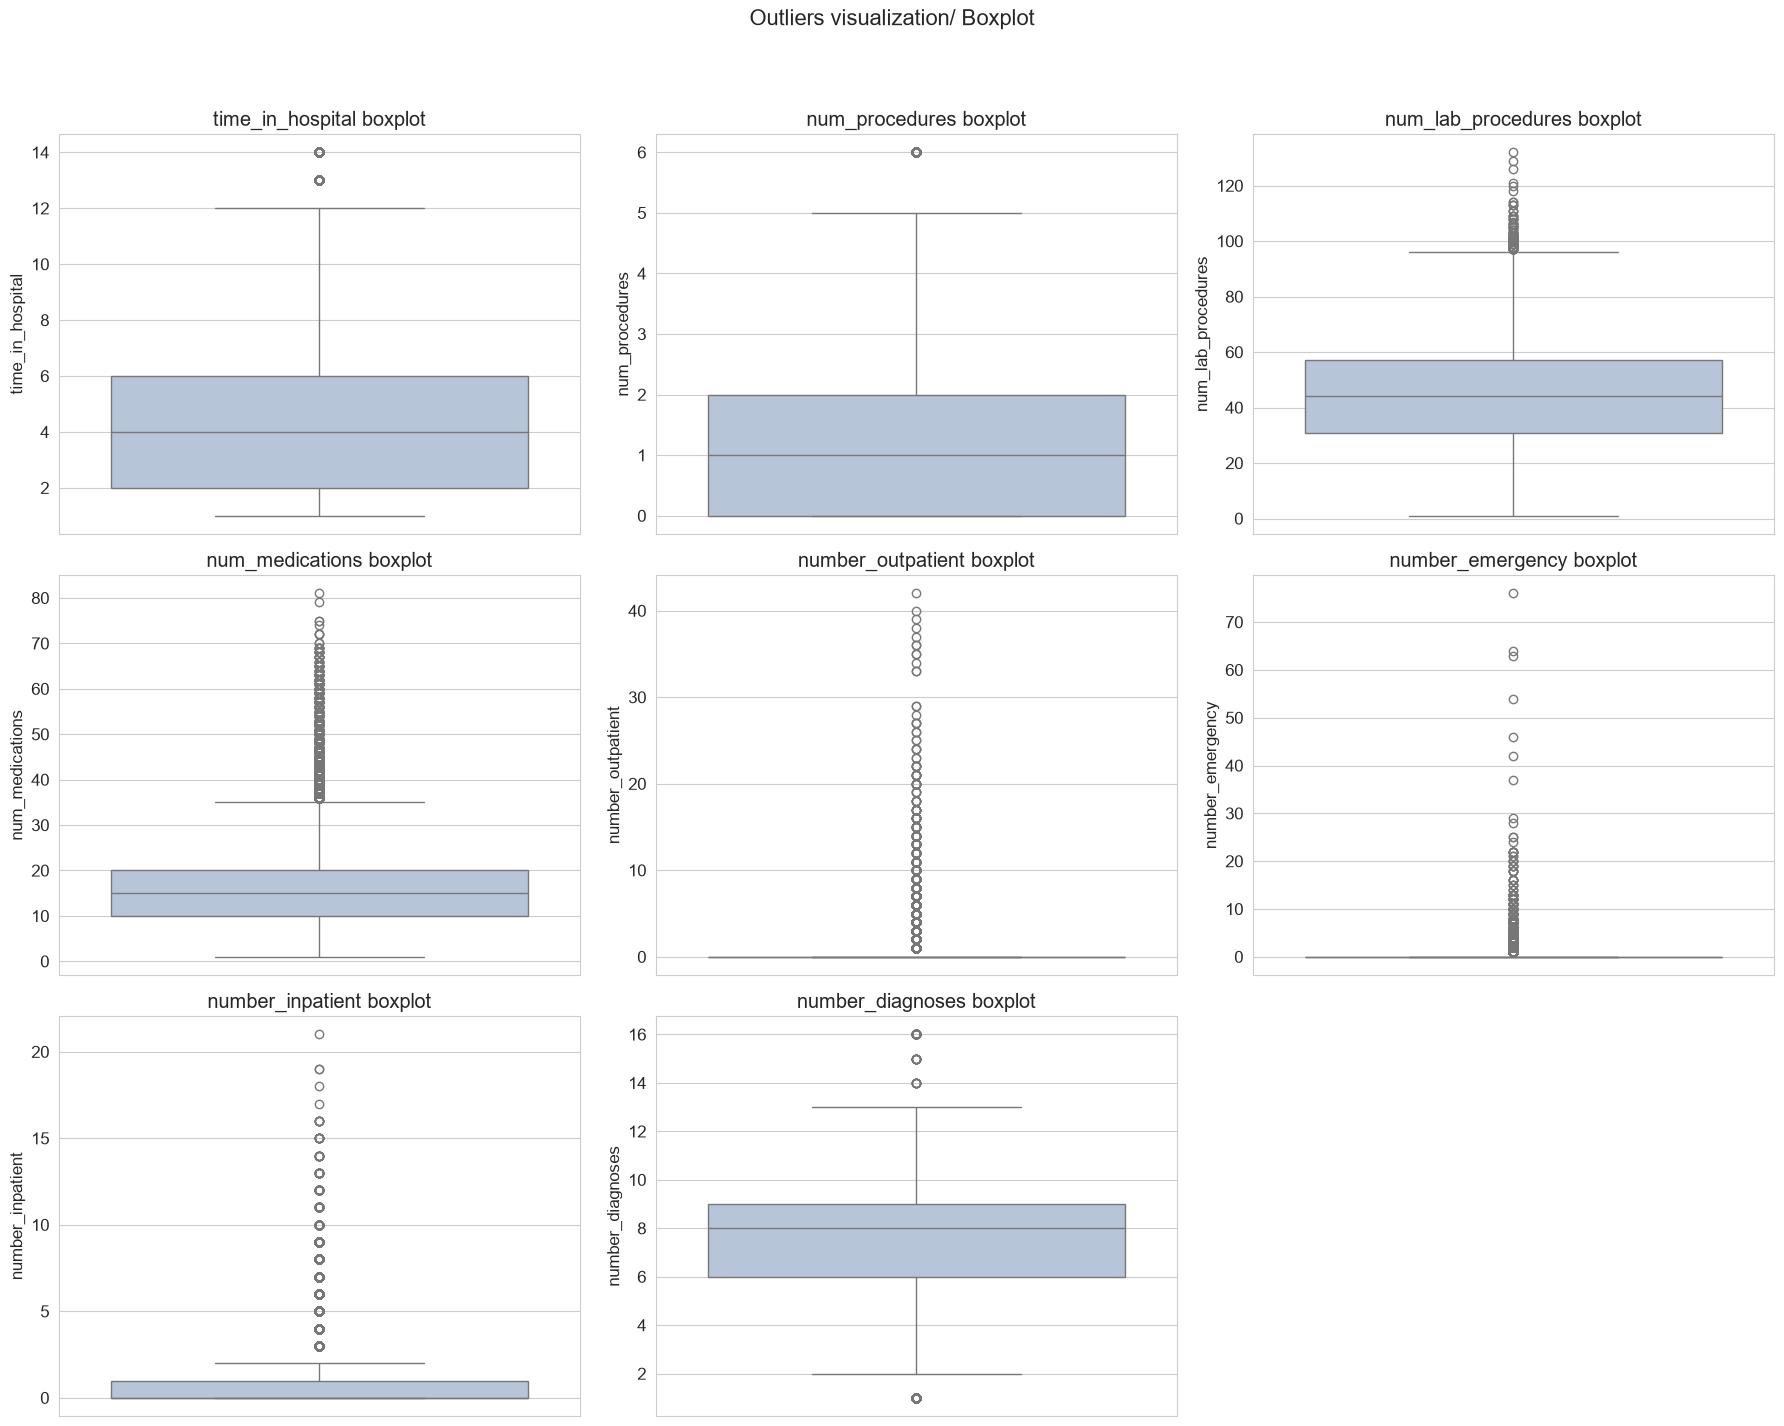

In [32]:
plot_outliers_boxplot(df)

**Conclusions**

Outliers were detected with IQR method.
Boxplots were made for visualization.

Although some extreme values are presented in this section, no observation will be removed.

Patients with complex medical history exist and extreme values are sometimes possible, so it´d be an error to erase them from this work.

## Cleaning Summary

- Some features were mapped, transforming ID numbers into their corresponding descriptions.
- Features with very low or null variability and possibly no useful predictive information were removed
- Very rare categories in medical_specialty were merged into one. One rare category in gender was removed.
- Outliers from numerical features were analyzed using IQR method, but still were kept in the dataset.

# Duplicates

In [33]:
find_and_display_duplicates(df)

No se encontraron filas duplicadas.


,encounter_id,race,gender,age,time_in_hospital,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,...,rosiglitazone,acarbose,insulin,glyburide-metformin,change,diabetesMed,readmitted,admission_type,discharge_disposition,admission_source


# Final Summary

Dataset has been cleaned removing non informative features, handling missing values, adjusting some categorical variables, studying numerical features and checking for duplicates. 

Cleaned dataset is ready for preprocessing.

# Saving cleaned dataset

In [36]:
df.to_csv("../data/processed/diabetes_clean.csv", index=False)